# Proyecto de Visión Computacional  
## Clasificación de defectos en superficies metálicas

### Problema
Dada una imagen de una superficie metálica, se quiere identificar automáticamente a qué clase de defecto pertenece.

### Estrategia
Se va a comparar cuatro modelos:

1. **CNN básica** entrenada desde cero → sirve como **baseline**.
2. **ResNet-18** con transfer learning.
3. **EfficientNet-B0** con transfer learning.
4. **MobileNetV3-Small** con transfer learning.

**Datos:** `industrial_defect_dataset/train` y `val` (PNG 256×256, grayscale → RGB para ImageNet)  

### Métricas principales
- Accuracy
- F1 macro
- Precision y recall por clase
- Matriz de confusión
- Curvas de entrenamiento

## 1. Configuración e imports

In [2]:
from __future__ import annotations

import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import (
    EfficientNet_B0_Weights,
    MobileNet_V3_Small_Weights,
    ResNet18_Weights,
)
from tqdm.auto import tqdm


In [3]:

# RUTAS

# Se usan rutas relativas para que el proyecto funcione en cualquier computadora después de hacer git clone.
ROOT = Path(".").resolve()

DATA_DIR = ROOT / "industrial_defect_dataset"
OUTPUT_DIR = ROOT / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURES_DIR = ROOT / "docs" / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# HIPERPARÁMETROS

# Semilla:
# permite repetir el experimento bajo condiciones similares.
SEED = 42

# Tamaño de entrada:
# el dataset trabaja con imágenes de 256x256, por eso se mantiene esta resolución.
IMG_SIZE = 256

# Batch size:
# se procesan 32 imágenes por iteración. Es un valor intermedio entre estabilidad y consumo de memoria.
BATCH_SIZE = 32

# Máximo de épocas:
# el modelo puede recorrer el dataset hasta 20 veces. Early stopping puede detenerlo antes.
NUM_EPOCHS = 20

# Learning rate:
# controla qué tan grandes son los cambios en los pesos. 3e-4 es un valor pequeño y común para fine-tuning.
LR = 3e-4

# Weight decay:
# regularización que ayuda a reducir sobreajuste.
WEIGHT_DECAY = 1e-4

# Early stopping:
# si F1 macro no mejora durante 5 épocas seguidas, se detiene el entrenamiento.
PATIENCE = 5

# En WSL podemos dejar 2 workers.
# Si hubiera problemas con el DataLoader, cambiar temporalmente a 0.
NUM_WORKERS = 2


# Orden de comparación:
# primero la CNN básica y luego los modelos preentrenados.
MODELS_TO_TRAIN = [
    "cnn_baseline",
    "resnet18",
    "efficientnet_b0",
    "mobilenet_v3_small",
]

# DISPOSITIVO
# ============================================================

# Si existe una GPU NVIDIA compatible con CUDA, se utiliza. Si no, la notebook funciona en CPU.
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda:0" if USE_CUDA else "cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo seleccionado: {DEVICE}")

if USE_CUDA:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA no disponible. El entrenamiento se realizará en CPU.")


PyTorch: 2.13.0+cpu
Dispositivo seleccionado: cpu
CUDA no disponible. El entrenamiento se realizará en CPU.


In [4]:
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Estas opciones ayudan a mejorar la reproducibilidad en CUDA.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

print(f"Semilla fijada en: {SEED}")


Semilla fijada en: 42


## 2. Dataset y DataLoaders

Las imágenes son grayscale (`L`). Se convierten a RGB (3 canales) para usar pesos ImageNet.

In [5]:
# Valores estándar de normalización utilizados por los modelos de ImageNet.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transformaciones para entrenamiento.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # El dataset es grayscale, pero los modelos preentrenados
    # esperan una entrada RGB de 3 canales.
    transforms.Grayscale(num_output_channels=3),

    # Data augmentation.
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),

    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
# Transformaciones para validación.

val_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ]
)

train_ds = datasets.ImageFolder(DATA_DIR / "train", transform=train_transform)
val_ds = datasets.ImageFolder(DATA_DIR / "val", transform=val_transform)

# Se verifica que train y val tengan exactamente las mismas clases.

assert train_ds.classes == val_ds.classes, (
    "Las clases de train y val no coinciden."
)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

print("Clases encontradas:", CLASS_NAMES)
print(f"Cantidad de clases: {NUM_CLASSES}")
print(f"Imágenes de entrenamiento: {len(train_ds)}")
print(f"Imágenes de validación: {len(val_ds)}")



Clases encontradas: ['crack', 'hole', 'normal', 'rust', 'scratch']
Cantidad de clases: 5
Imágenes de entrenamiento: 12000
Imágenes de validación: 3000


In [6]:
# Distribución de clases
train_counts = np.bincount(
    train_ds.targets,
    minlength=NUM_CLASSES
)

val_counts = np.bincount(
    val_ds.targets,
    minlength=NUM_CLASSES
)

class_distribution = pd.DataFrame({
    "clase": CLASS_NAMES,
    "train": train_counts,
    "val": val_counts,
    "total": train_counts + val_counts,
})

class_distribution

,clase,train,val,total
0,crack,2400,600,3000
1,hole,2400,600,3000
2,normal,2400,600,3000
3,rust,2400,600,3000
4,scratch,2400,600,3000


### DataLoaders

El `DataLoader` entrega las imágenes al modelo por lotes.

- En **train** se usa `shuffle=True` para variar el orden de las imágenes.
- En **validation** se usa`shuffle=False` porque no se necesita aleatoriedad al evaluar.

In [7]:
generator = torch.Generator()
generator.manual_seed(SEED)

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": USE_CUDA,
}

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

images_batch, labels_batch = next(iter(train_loader))

print("Forma del batch:", images_batch.shape)
print("Ejemplo de etiquetas:", labels_batch[:10])


Forma del batch: torch.Size([32, 3, 256, 256])
Ejemplo de etiquetas: tensor([4, 1, 2, 0, 3, 0, 0, 4, 4, 1])


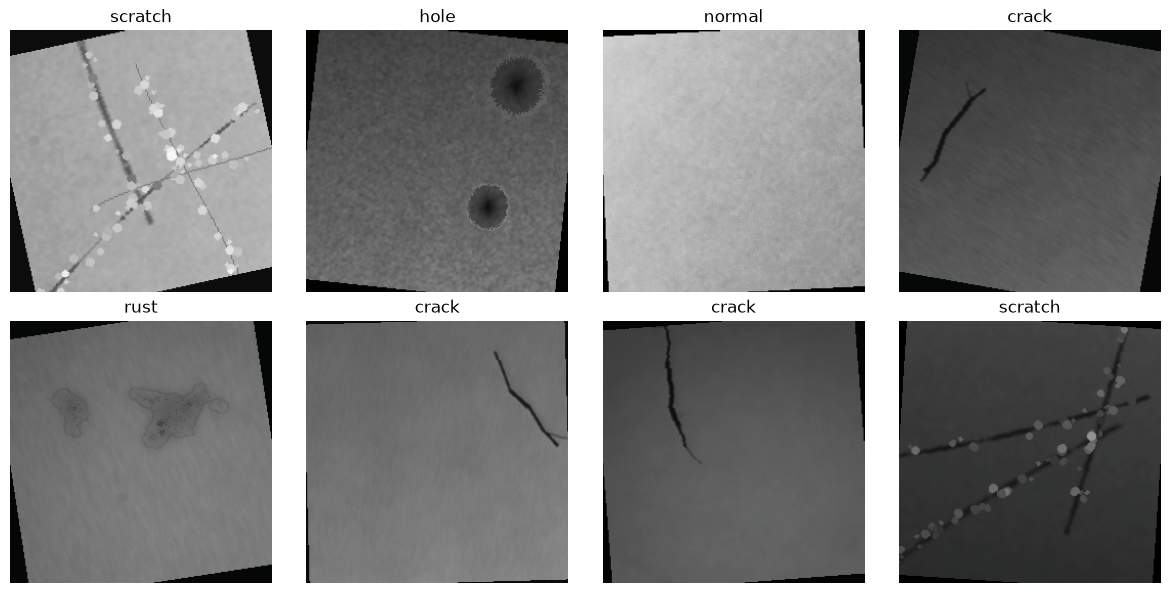

In [ ]:
#  Visualización rápida de imágenes
def desnormalizar(img):
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)


fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, img, label in zip(
    axes.ravel(),
    images_batch[:8],
    labels_batch[:8]
):
    ax.imshow(desnormalizar(img))
    ax.set_title(CLASS_NAMES[int(label)])
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Modelos 

### 3.1 CNN básica — baseline

La CNN se entrena **desde cero**.

La arquitectura usa:

- convoluciones para extraer patrones,
- ReLU como función de activación,
- MaxPooling para reducir dimensiones,
- Batch Normalization para estabilizar el entrenamiento,
- Dropout para regularización,
- una capa final para clasificar las 5 categorías.

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            # Bloque 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 4
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Reduce cada mapa de características a un solo valor.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),

            # Dropout ayuda a reducir sobreajuste.
            nn.Dropout(0.30),

            # Salida final: una neurona por clase.
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


### 3.2 Modelos preentrenados

Se usa transfer learning con tres arquitecturas conocidas:

- **ResNet-18:** modelo relativamente compacto y muy utilizado; sus conexiones residuales facilitan el entrenamiento.
- **EfficientNet-B0:** busca buen equilibrio entre precisión y cantidad de parámetros.
- **MobileNetV3-Small:** modelo ligero, interesante para una futura aplicación en hardware limitado.



In [10]:
def build_model(name, num_classes=NUM_CLASSES):

    name = name.lower()

    # CNN básica entrenada desde cero

    if name == "cnn_baseline":
        model = SimpleCNN(num_classes)

    # ResNet-18 preentrenada en ImageNet

    elif name == "resnet18":
        model = models.resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )

    # EfficientNet-B0 preentrenada en ImageNet

    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        in_features = model.classifier[1].in_features

        model.classifier[1] = nn.Linear(
            in_features,
            num_classes
        )

    # MobileNetV3-Small preentrenada en ImageNet

    elif name == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(
            weights=MobileNet_V3_Small_Weights.DEFAULT
        )

        in_features = model.classifier[3].in_features

        model.classifier[3] = nn.Linear(
            in_features,
            num_classes
        )

    else:
        raise ValueError(f"Modelo no reconocido: {name}")

    return model


In [11]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


for model_name in MODELS_TO_TRAIN:

    model = build_model(model_name)

    print(
        f"{model_name:22s} "
        f"parámetros entrenables: {count_parameters(model):,}"
    )


cnn_baseline           parámetros entrenables: 390,661
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jennisg/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:10<00:00, 4.65MB/s]


resnet18               parámetros entrenables: 11,179,077
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/jennisg/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:05<00:00, 4.28MB/s]


efficientnet_b0        parámetros entrenables: 4,013,953
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/jennisg/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:02<00:00, 4.56MB/s]

mobilenet_v3_small     parámetros entrenables: 1,522,981



## 4. Función de pérdida y optimizador

### CrossEntropyLoss
Se usa porque el problema es de **clasificación multiclase**: cada imagen pertenece a una sola clase.

### AdamW
Se usa AdamW porque combina el comportamiento adaptativo de Adam con una forma adecuada de aplicar `weight_decay`.



## 5. Funciones de evaluación

Además de accuracy se calcula **F1 macro**.

F1 macro calcula el F1 de cada clase por separado y luego obtiene el promedio, dando la misma importancia a todas las clases.

In [12]:
torch.no_grad()
def evaluate(model, loader):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    all_predictions = []
    all_labels = []

    for inputs, targets in loader:

        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        total_loss += (
            loss.item() * inputs.size(0)
        )

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            targets.cpu().numpy()
        )

    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "y_true": y_true,
        "y_pred": y_pred,
    }


## 6. Entrenamiento

Esta función realiza el entrenamiento de un modelo.

Se usa **early stopping tomando F1 macro como referencia**:

- si F1 mejora, se guarda el modelo;
- si no mejora durante varias épocas, se detiene el entrenamiento.

Esto evita seguir entrenando cuando ya no se observa una mejora útil.

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in tqdm(
        loader,
        leave=False
    ):

        inputs = inputs.to(DEVICE)
        targets = targets.to(DEVICE)

        # Eliminar gradientes anteriores.
        optimizer.zero_grad()

        # Forward:
        # el modelo genera una predicción.
        outputs = model(inputs)

        # Calcular el error.
        loss = criterion(
            outputs,
            targets
        )

        # Backpropagation.
        loss.backward()

        # Actualizar los pesos.
        optimizer.step()

        running_loss += (
            loss.item() * inputs.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == targets
        ).sum().item()

        total += targets.size(0)

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy


In [ ]:
def train_model(model_name):

    # Reiniciar la semilla antes de cada modelo.
    set_seed()

    model = build_model(
        model_name
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
    }

    best_f1 = -1
    best_state = None
    epochs_without_improvement = 0

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"{model_name}_best.pt"
    )

    print(
        f"\nEntrenando {model_name} "
        f"en {DEVICE}"
    )

    start_time = time.time()

    for epoch in range(
        1,
        NUM_EPOCHS + 1
    ):

        train_loss, train_acc = (
            train_one_epoch(
                model,
                train_loader,
                optimizer,
                criterion
            )
        )

        val_metrics = evaluate(
            model,
            val_loader
        )

        history["epoch"].append(epoch)
        history["train_loss"].append(
            train_loss
        )
        history["train_acc"].append(
            train_acc
        )
        history["val_loss"].append(
            val_metrics["loss"]
        )
        history["val_acc"].append(
            val_metrics["accuracy"]
        )
        history["val_f1"].append(
            val_metrics["f1_macro"]
        )

        print(
            f"Época {epoch:02d}/{NUM_EPOCHS} | "
            f"train_acc={train_acc:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_f1={val_metrics['f1_macro']:.4f}"
        )

        # Guardar el mejor modelo según F1 macro.
        if val_metrics["f1_macro"] > best_f1:

            best_f1 = (
                val_metrics["f1_macro"]
            )

            best_state = {
                key: value.detach().cpu().clone()
                for key, value
                in model.state_dict().items()
            }

            epochs_without_improvement = 0

            torch.save(
                {
                    "model_name": model_name,
                    "state_dict": best_state,
                    "class_names": CLASS_NAMES,
                    "img_size": IMG_SIZE,
                    "metrics": {
                        "accuracy":
                            val_metrics["accuracy"],
                        "f1_macro":
                            val_metrics["f1_macro"],
                        "f1_weighted":
                            val_metrics["f1_weighted"],
                    },
                },
                checkpoint_path
            )

        else:

            epochs_without_improvement += 1

            if (
                epochs_without_improvement
                >= PATIENCE
            ):

                print(
                    "Early stopping: "
                    "el F1 macro dejó de mejorar."
                )

                break

    training_time = (
        time.time() - start_time
    )

    # Recuperar el mejor estado.
    model.load_state_dict(
        best_state
    )

    final_metrics = evaluate(
        model,
        val_loader
    )

    return {
        "model": model_name,
        "params":
            count_parameters(model),
        "epochs_run":
            len(history["epoch"]),
        "seconds":
            training_time,
        "accuracy":
            final_metrics["accuracy"],
        "f1_macro":
            final_metrics["f1_macro"],
        "f1_weighted":
            final_metrics["f1_weighted"],
        "checkpoint":
            str(checkpoint_path),
        "history":
            history,
        "y_true":
            final_metrics["y_true"],
        "y_pred":
            final_metrics["y_pred"],
    }


## 7. Entrenamiento de los cuatro modelos

El entrenamiento puede tardar bastante en CPU.

In [ ]:
results = []

for model_name in MODELS_TO_TRAIN:

    result = train_model(
        model_name
    )

    results.append(result)



Entrenando cnn_baseline en cpu


  0%|          | 0/375 [00:00<?, ?it/s]

## 8. Tabla comparativa de resultados

La tabla permite comparar:

- precisión global,
- F1 macro,
- F1 weighted,
- cantidad de parámetros,
- épocas ejecutadas,
- tiempo de entrenamiento.



In [ ]:
summary = pd.DataFrame([
    {
        "model": r["model"],
        "accuracy": r["accuracy"],
        "f1_macro": r["f1_macro"],
        "f1_weighted": r["f1_weighted"],
        "params": r["params"],
        "epochs": r["epochs_run"],
        "minutes": r["seconds"] / 60,
        "checkpoint": r["checkpoint"],
    }
    for r in results
])

summary = summary.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

summary


## 9. Curvas de entrenamiento

Aquí se muestra **train vs validation** para cada modelo.

### ¿Qué se busca?
- Si train mejora pero validation empeora, puede haber **sobreajuste**.
- Si ambas curvas son malas, puede haber **subajuste**.
- Si ambas mejoran y se mantienen próximas, es una señal positiva.

In [ ]:
for r in results:

    history = r["history"]

    # Curva de pérdida

    plt.figure(figsize=(7, 4))

    plt.plot(
        history["epoch"],
        history["train_loss"],
        marker="o",
        label="Train loss"
    )

    plt.plot(
        history["epoch"],
        history["val_loss"],
        marker="s",
        label="Validation loss"
    )

    plt.title(
        f"{r['model']} - Loss"
    )

    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        f"{r['model']}_loss.png",
        dpi=150
    )

    plt.show()


    # Curva de accuracy
 
    plt.figure(figsize=(7, 4))

    plt.plot(
        history["epoch"],
        history["train_acc"],
        marker="o",
        label="Train accuracy"
    )

    plt.plot(
        history["epoch"],
        history["val_acc"],
        marker="s",
        label="Validation accuracy"
    )

    plt.title(
        f"{r['model']} - Accuracy"
    )

    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.02)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        f"{r['model']}_accuracy.png",
        dpi=150
    )

    plt.show()


Pérdida guardada en: G:\Maestria\Modulo 9\Proyecto Final\docs\figures\loss_curves.png


Precisión guardada en: G:\Maestria\Modulo 9\Proyecto Final\docs\figures\accuracy_curves.png


## 10. Matrices de confusión

La matriz de confusión permite analizar **en qué clases se equivoca el modelo**.

Esto es importante porque una sola cifra de accuracy no muestra qué defectos se están confundiendo entre sí.


In [ ]:
for r in results:

    cm = confusion_matrix(
        r["y_true"],
        r["y_pred"]
    )

    plt.figure(
        figsize=(7, 6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )

    plt.title(
        f"Matriz de confusión - {r['model']}"
    )

    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR /
        f"{r['model']}_confusion_matrix.png",
        dpi=150
    )

    plt.show()


Matrices guardadas en: G:\Maestria\Modulo 9\Proyecto Final\docs\figures\confusion_matrices.png

resnet18
              precision    recall  f1-score   support

       crack     1.0000    1.0000    1.0000       600
        hole     1.0000    1.0000    1.0000       600
      normal     1.0000    1.0000    1.0000       600
        rust     1.0000    1.0000    1.0000       600
     scratch     1.0000    1.0000    1.0000       600

    accuracy                         1.0000      3000
   macro avg     1.0000    1.0000    1.0000      3000
weighted avg     1.0000    1.0000    1.0000      3000


efficientnet_b0
              precision    recall  f1-score   support

       crack     1.0000    1.0000    1.0000       600
        hole     1.0000    1.0000    1.0000       600
      normal     1.0000    1.0000    1.0000       600
        rust     1.0000    1.0000    1.0000       600
     scratch     1.0000    1.0000    1.0000       600

    accuracy                         1.0000      3000
   macro 

## 11. Precision, recall y F1 por clase

Estas métricas permiten comprobar si el modelo funciona bien para **todas las categorías** y no solo de forma global.


In [ ]:
for r in results:

    print(
        "\n" + "=" * 70
    )

    print(r["model"])

    print(
        classification_report(
            r["y_true"],
            r["y_pred"],
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0
        )
    )


## 12. Análisis de predicciones correctas e incorrectas
La siguiente función muestra ejemplos del conjunto de validación y separa:

- predicciones correctas,
- predicciones incorrectas.

In [ ]:
def load_best_model(result):

    model_name = result["model"]

    checkpoint = torch.load(
        result["checkpoint"],
        map_location=DEVICE
    )

    model = build_model(
        model_name
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["state_dict"]
    )

    model.eval()

    return model


In [ ]:
@torch.no_grad()
def collect_predictions(
    model,
    loader,
    max_items=200
):

    examples = []

    for images, labels in loader:

        images_device = images.to(DEVICE)

        outputs = model(
            images_device
        )

        predictions = outputs.argmax(
            dim=1
        ).cpu()

        for img, true_label, pred_label in zip(
            images,
            labels,
            predictions
        ):

            examples.append({
                "image": img,
                "true": int(true_label),
                "pred": int(pred_label),
                "correct":
                    int(true_label)
                    == int(pred_label),
            })

            if len(examples) >= max_items:
                return examples

    return examples


In [ ]:
best_result = results[
    int(
        np.argmax([
            r["f1_macro"]
            for r in results
        ])
    )
]

best_model = load_best_model(
    best_result
)

examples = collect_predictions(
    best_model,
    val_loader
)

correct_examples = [
    x for x in examples
    if x["correct"]
]

incorrect_examples = [
    x for x in examples
    if not x["correct"]
]

print(
    f"Mejor modelo: {best_result['model']}"
)

print(
    f"Correctas encontradas: {len(correct_examples)}"
)

print(
    f"Incorrectas encontradas: {len(incorrect_examples)}"
)


In [ ]:
def show_examples(
    examples,
    title,
    n=10
):

    selected = examples[:n]

    if len(selected) == 0:
        print(
            f"No se encontraron ejemplos para: {title}"
        )
        return

    cols = 5
    rows = int(
        np.ceil(
            len(selected) / cols
        )
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 3 * rows)
    )

    axes = np.array(
        axes
    ).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, example in zip(
        axes,
        selected
    ):

        ax.imshow(
            desnormalizar(
                example["image"]
            )
        )

        true_name = CLASS_NAMES[
            example["true"]
        ]

        pred_name = CLASS_NAMES[
            example["pred"]
        ]

        ax.set_title(
            f"Real: {true_name}\n"
            f"Pred: {pred_name}",
            fontsize=9
        )

        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
show_examples(
    correct_examples,
    "Ejemplos de predicciones correctas",
    n=10
)

show_examples(
    incorrect_examples,
    "Ejemplos de predicciones incorrectas",
    n=10
)


### Preguntas que se deben hacer al analizar errores

- ¿El defecto es pequeño o poco visible?
- ¿La imagen tiene bajo contraste?
- ¿Dos clases tienen patrones visuales parecidos?
- ¿La imagen sintética contiene artefactos?
- ¿El modelo parece estar aprendiendo textura en lugar del defecto?
- ¿Existe alguna señal de fuga de datos?



## 13. Guardar resultados y configuración

Guardar la configuración es importante para la **reproducibilidad**.

Así se podrá saber exactamente qué hiperparámetros generaron las métricas reportadas.


In [ ]:
experiment = {
    "seed": SEED,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs_max": NUM_EPOCHS,
    "learning_rate": LR,
    "weight_decay": WEIGHT_DECAY,
    "patience": PATIENCE,
    "device": str(DEVICE),
    "pytorch_version": torch.__version__,
    "classes": CLASS_NAMES,
    "train_size": len(train_ds),
    "val_size": len(val_ds),
    "models": summary.to_dict(
        orient="records"
    ),
}

config_path = (
    OUTPUT_DIR /
    "experiment_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        experiment,
        file,
        indent=2,
        ensure_ascii=False
    )

print(
    f"Configuración guardada en: {config_path}"
)
